In [87]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [88]:
df = pd.read_csv("svm_employee_attrition_dataset.csv")

In [89]:
#Task 1 (Dataset Create)
df.head()

,age,monthly_income,years_at_company,job_satisfaction,work_life_balance,attrition
0,22,18000,0,1,1,1
1,24,20000,1,2,2,1
2,25,22000,1,2,2,1
3,26,24000,2,3,3,0
4,27,26000,2,3,3,0


In [90]:
df.columns

Index(['age', 'monthly_income', 'years_at_company', 'job_satisfaction',
       'work_life_balance', 'attrition'],
      dtype='object')

In [91]:
# Task 2(preprocessing)
X = df[['monthly_income', 'years_at_company', 'job_satisfaction','work_life_balance']] #features
y = df['attrition']   #Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [92]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled, y, test_size=0.3)

In [93]:
# Taks 3 (Train svm Model)
model = SVC(kernel = 'rbf', C=1, gamma="scale")
model.fit(X_train,y_train)

SVC(C=1)

In [94]:
y_pred = model.predict(X_test)

In [95]:
#Task 4 (Evaluation)
print("Confusion Matrix :\n", confusion_matrix(y_test,y_pred))

print("\nClassification report :\n", classification_report(y_test,y_pred))

Confusion Matrix :
 [[11  0]
 [ 0  4]]

Classification report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



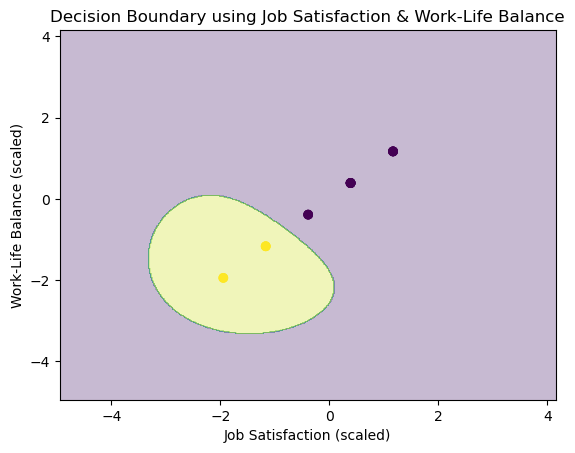

In [99]:
x_min, x_max = X_scaled[:,0].min()-3, X_scaled[:,0].max()+3
y_min, y_max = X_scaled[:,1].min()-3, X_scaled[:,1].max()+3

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# -----------------------------
# 7. Predict over grid
# -----------------------------
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# -----------------------------
# 8. Plot decision boundary
# -----------------------------
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y)
plt.xlabel("Job Satisfaction (scaled)")
plt.ylabel("Work-Life Balance (scaled)")
plt.title("Decision Boundary using Job Satisfaction & Work-Life Balance")
plt.show()

In [96]:
#Task 6 (New employee Attrition)
test = [[20000,1,1,1],[70000,8,4,5]]
test_s = scaler.transform(test)

model.predict(test_s)

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1, 0], dtype=int64)